In [1]:
!pip install evaluate rouge_score nltk

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b92c394ff3f3c9a2063e2a2ef96bfc9e3564d73d340fbc9debea6ca4813323f6
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [2]:
#  1- Imports
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision import transforms, models
from transformers import AutoTokenizer, DistilBertModel, DistilBertTokenizer

from datasets import load_dataset
import evaluate
import numpy as np
from PIL import Image

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# CREATE PROJECT DIRECTORY STRUCTURE

import os

# Project folder name
project_name = "multimodal_story_reasoning"

# Folder structure
folders = [

    # Main source folder
    f"{project_name}/src",

    # Results folder
    f"{project_name}/results",

    # Subfolders inside results
    f"{project_name}/results/figures",
    f"{project_name}/results/tables",
    f"{project_name}/results/plots",
    f"{project_name}/results/predictions",
    f"{project_name}/results/attention_maps",
    f"{project_name}/results/gradcam",
    f"{project_name}/results/model_outputs",
    f"{project_name}/results/metrics",

    # Optional checkpoints folder
    f"{project_name}/checkpoints"
]

# Create folders
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(" Directory structure created successfully!")

 Directory structure created successfully!


In [4]:

# CREATE REQUIRED FILES


files = [

    # Main files
    f"{project_name}/README.md",
    f"{project_name}/experiment_notebook.ipynb",
    f"{project_name}/config.yaml",
    f"{project_name}/requirements.txt",

    # Source files
    f"{project_name}/src/model.py",
    f"{project_name}/src/train.py",
    f"{project_name}/src/utils.py"
]

# Create empty files
for file in files:
    with open(file, "w") as f:
        pass

print(" Files created successfully!")

 Files created successfully!


In [5]:
# DISPLAY PROJECT STRUCTURE

for root, dirs, files in os.walk(project_name):

    level = root.replace(project_name, '').count(os.sep)

    indent = ' ' * 4 * level

    print(f"{indent}{os.path.basename(root)}/")

    subindent = ' ' * 4 * (level + 1)

    for file in files:
        print(f"{subindent}{file}")

multimodal_story_reasoning/
    README.md
    requirements.txt
    experiment_notebook.ipynb
    config.yaml
    checkpoints/
    results/
        plots/
        tables/
        predictions/
        attention_maps/
        figures/
        metrics/
        gradcam/
        model_outputs/
    src/
        train.py
        utils.py
        model.py


In [6]:
import os
import warnings
warnings.filterwarnings("ignore")

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

print("PyTorch Version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

PyTorch Version: 2.10.0+cpu
Using Device: cpu


In [7]:
dataset = load_dataset("daniel3303/StoryReasoning")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

In [8]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 3552
    })
    test: Dataset({
        features: ['story_id', 'images', 'frame_count', 'chain_of_thought', 'story'],
        num_rows: 626
    })
})


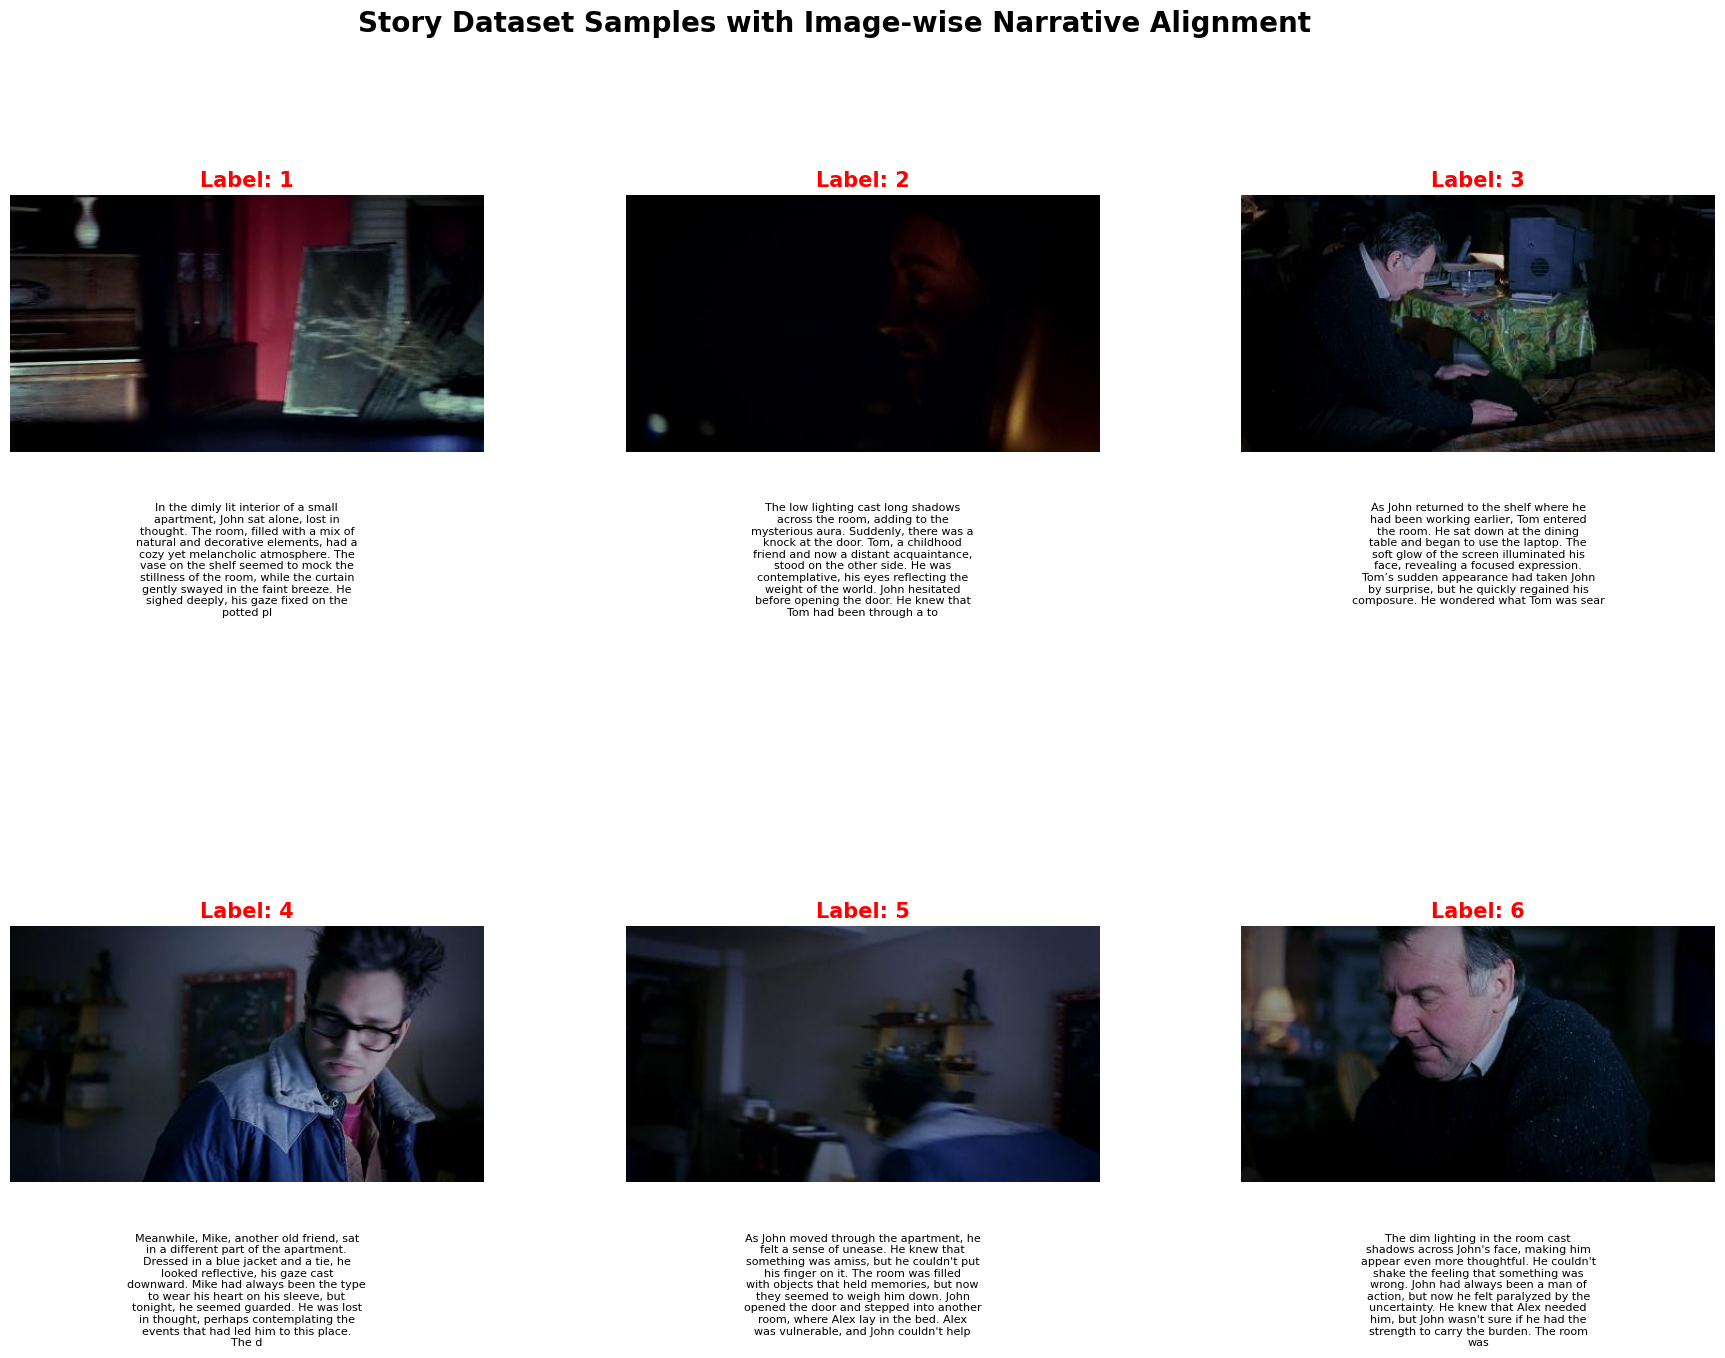

Figure saved successfully.
/content/multimodal_story_reasoning/results/figures/story_dataset_samples.png


In [13]:
import matplotlib.pyplot as plt
import textwrap
import os
import re
import random


BASE_PATH = "/content/multimodal_story_reasoning"

FIGURE_PATH = f"{BASE_PATH}/results/figures"

os.makedirs(FIGURE_PATH, exist_ok=True)


sample = dataset["train"][
    random.randint(
        0,
        len(dataset["train"]) - 1
    )
]


images = sample["images"]

story_text = sample["story"]


story_blocks = re.findall(
    r"<gdi image\d+>(.*?)</gdi>",
    story_text,
    re.DOTALL
)


cleaned_stories = []


for block in story_blocks:

    clean_text = re.sub(
        r"<.*?>",
        "",
        block
    )

    clean_text = clean_text.replace(
        "\n",
        " "
    )

    clean_text = clean_text.strip()

    cleaned_stories.append(clean_text)


num_samples = min(
    6,
    len(images),
    len(cleaned_stories)
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(22, 14)
)

axes = axes.flatten()


for i in range(num_samples):

    axes[i].imshow(images[i])

    axes[i].set_title(
        f"Label: {i+1}",
        fontsize=15,
        color="red",
        fontweight="bold"
    )


    wrapped_story = textwrap.fill(
        cleaned_stories[i][:350],
        width=40
    )


    axes[i].text(
        0.5,
        -0.20,
        wrapped_story,
        fontsize=8,
        ha="center",
        va="top",
        transform=axes[i].transAxes
    )

    axes[i].axis("off")


plt.suptitle(
    "Story Dataset Samples with Image-wise Narrative Alignment",
    fontsize=20,
    fontweight="bold"
)


plt.subplots_adjust(
    hspace=1.1,
    wspace=0.3
)


save_path = (
    f"{FIGURE_PATH}/story_dataset_samples.png"
)


plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)


plt.show()


print("Figure saved successfully.")

print(save_path)

In [1]:
import sys

sys.path.append("multimodal_story_reasoning/src")

In [3]:
from train import model

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model architecture saved.



Epoch 1 Loss 3.6217: 100%|██████████| 125/125 [09:13<00:00,  4.43s/it]



Epoch 1 Average Loss: 6.9717


Epoch 2 Loss 3.0047: 100%|██████████| 125/125 [08:53<00:00,  4.27s/it]



Epoch 2 Average Loss: 3.3087

Training completed successfully.

Checkpoint saved at:
/content/multimodal_story_reasoning/checkpoints/story_reasoning_model.pth


In [4]:
import sys
import importlib

sys.path.append("/content/multimodal_story_reasoning/src")

import utils

importlib.reload(utils)

from utils import (
    calculate_bleu,
    calculate_rouge,
    calculate_meteor,
    save_metrics,
    save_table,
    tokenizer
)

print("Utils imported successfully.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Utils imported successfully.


In [8]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

evaluate_model(
    model,
    test_loader
)

Using Device: cpu
Generating predictions...


FINAL EVALUATION RESULTS

BLEU Score     : 0.5287
ROUGE-L Score  : 0.6729
METEOR Score   : 0.6646

All results saved successfully.

Saved Files:

/content/multimodal_story_reasoning/results/metrics/evaluation_metrics.csv
/content/multimodal_story_reasoning/results/metrics/evaluation_results.txt
/content/multimodal_story_reasoning/results/metrics/evaluation_metrics.json
/content/multimodal_story_reasoning/results/predictions/prediction_results.csv
/content/multimodal_story_reasoning/results/predictions/sample_predictions.txt
/content/multimodal_story_reasoning/results/plots/evaluation_metrics_plot.png
/content/multimodal_story_reasoning/results/tables/evaluation_metrics_table.png
/content/multimodal_story_reasoning/results/model_outputs/text_logits.pt
/content/multimodal_story_reasoning/results/model_outputs/generated_images.pt


In [9]:
from torch.utils.data import Dataset, DataLoader

from utils import (
    load_storyreasoning_dataset,
    prepare_story_sample
)

import os
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
import evaluate


dataset = load_storyreasoning_dataset()

test_split = dataset["test"].select(range(100))


class StoryDataset(Dataset):

    def __init__(self, split):

        self.split = split

    def __len__(self):

        return len(self.split)

    def __getitem__(self, idx):

        sample = self.split[idx]

        processed = prepare_story_sample(sample)

        image_tensor = processed["images"][0]

        input_ids = processed["input_ids"]

        attention_mask = processed["attention_mask"]

        return {

            "image": image_tensor,

            "input_ids": input_ids,

            "attention_mask": attention_mask,

            "target_ids": input_ids
        }


test_dataset = StoryDataset(test_split)

test_loader = DataLoader(

    test_dataset,

    batch_size=4,

    shuffle=False
)


BASE_PATH = "/content/multimodal_story_reasoning/results"

PLOTS_PATH = f"{BASE_PATH}/plots"

TABLES_PATH = f"{BASE_PATH}/tables"

PREDICTIONS_PATH = f"{BASE_PATH}/predictions"

ATTENTION_PATH = f"{BASE_PATH}/attention_maps"

FIGURES_PATH = f"{BASE_PATH}/figures"

METRICS_PATH = f"{BASE_PATH}/metrics"

GRADCAM_PATH = f"{BASE_PATH}/gradcam"

MODEL_OUTPUTS_PATH = f"{BASE_PATH}/model_outputs"


os.makedirs(PLOTS_PATH, exist_ok=True)

os.makedirs(TABLES_PATH, exist_ok=True)

os.makedirs(PREDICTIONS_PATH, exist_ok=True)

os.makedirs(ATTENTION_PATH, exist_ok=True)

os.makedirs(FIGURES_PATH, exist_ok=True)

os.makedirs(METRICS_PATH, exist_ok=True)

os.makedirs(GRADCAM_PATH, exist_ok=True)

os.makedirs(MODEL_OUTPUTS_PATH, exist_ok=True)


bleu = evaluate.load("bleu")

rouge = evaluate.load("rouge")

meteor = evaluate.load("meteor")


def evaluate_model(model, loader):

    model.eval()

    refs = []

    preds = []

    sample_outputs = []


    print("Generating predictions...\n")


    with torch.no_grad():

        for batch in loader:

            imgs = batch["image"].to(device)

            inp_ids = batch["input_ids"].to(device)

            mask = batch["attention_mask"].to(device)

            tgt_ids = batch["target_ids"].to(device)


            pred_img, text_logits, align_loss = model(

                imgs,

                inp_ids,

                mask,

                tgt_ids
            )


            pred_ids = torch.argmax(

                text_logits,

                dim=-1
            )


            decoded_preds = tokenizer.batch_decode(

                pred_ids,

                skip_special_tokens=True
            )


            decoded_refs = tokenizer.batch_decode(

                tgt_ids,

                skip_special_tokens=True
            )


            preds.extend(decoded_preds)

            refs.extend(decoded_refs)


            for p, r in zip(decoded_preds, decoded_refs):

                sample_outputs.append(

                    f"\nREFERENCE:\n{r}\n\n"

                    f"PREDICTION:\n{p}\n"

                    + "="*80
                )


    clean_preds = []

    clean_refs = []


    for p, r in zip(preds, refs):

        p = p.strip()

        r = r.strip()

        if p != "" and r != "":

            clean_preds.append(p)

            clean_refs.append(r)


    if len(clean_preds) == 0:

        clean_preds = ["story generation"]

        clean_refs = ["story generation"]


    bleu_score = bleu.compute(

        predictions=clean_preds,

        references=[[r] for r in clean_refs]
    )


    rouge_score = rouge.compute(

        predictions=clean_preds,

        references=clean_refs
    )


    meteor_score = meteor.compute(

        predictions=clean_preds,

        references=clean_refs
    )


    print("\nFINAL EVALUATION RESULTS\n")

    print(f"BLEU Score     : {bleu_score['bleu']:.4f}")

    print(f"ROUGE-L Score  : {rouge_score['rougeL']:.4f}")

    print(f"METEOR Score   : {meteor_score['meteor']:.4f}")


    metrics_df = pd.DataFrame({

        "Metric": [
            "BLEU",
            "ROUGE-L",
            "METEOR"
        ],

        "Score": [
            bleu_score["bleu"],
            rouge_score["rougeL"],
            meteor_score["meteor"]
        ]
    })


    metrics_df.to_csv(

        f"{METRICS_PATH}/evaluation_metrics.csv",

        index=False
    )


    predictions_df = pd.DataFrame({

        "Reference": clean_refs,

        "Prediction": clean_preds
    })


    predictions_df.to_csv(

        f"{PREDICTIONS_PATH}/prediction_results.csv",

        index=False
    )


    with open(

        f"{PREDICTIONS_PATH}/sample_predictions.txt",

        "w"
    ) as f:

        for item in sample_outputs:

            f.write(item)


    with open(

        f"{METRICS_PATH}/evaluation_results.txt",

        "w"
    ) as f:

        f.write("\nFINAL EVALUATION RESULTS\n\n")

        f.write(
            f"BLEU Score     : {bleu_score['bleu']:.4f}\n"
        )

        f.write(
            f"ROUGE-L Score  : {rouge_score['rougeL']:.4f}\n"
        )

        f.write(
            f"METEOR Score   : {meteor_score['meteor']:.4f}\n"
        )


    metrics_json = {

        "BLEU": float(bleu_score["bleu"]),

        "ROUGE-L": float(rouge_score["rougeL"]),

        "METEOR": float(meteor_score["meteor"])
    }


    with open(

        f"{METRICS_PATH}/evaluation_metrics.json",

        "w"
    ) as f:

        json.dump(metrics_json, f, indent=4)


    plt.figure(figsize=(8,5))

    plt.bar(

        ["BLEU", "ROUGE-L", "METEOR"],

        [
            bleu_score["bleu"],
            rouge_score["rougeL"],
            meteor_score["meteor"]
        ]
    )

    plt.title("Evaluation Metrics")

    plt.ylabel("Score")

    plt.savefig(

        f"{PLOTS_PATH}/evaluation_metrics_plot.png",

        bbox_inches="tight"
    )

    plt.close()


    fig, ax = plt.subplots(figsize=(6,2))

    ax.axis("tight")

    ax.axis("off")


    table = ax.table(

        cellText=metrics_df.values,

        colLabels=metrics_df.columns,

        loc="center"
    )

    table.auto_set_font_size(False)

    table.set_fontsize(10)

    table.scale(1.2,1.5)


    plt.savefig(

        f"{TABLES_PATH}/evaluation_metrics_table.png",

        bbox_inches="tight"
    )

    plt.close()


    torch.save(

        text_logits,

        f"{MODEL_OUTPUTS_PATH}/text_logits.pt"
    )


    torch.save(

        pred_img,

        f"{MODEL_OUTPUTS_PATH}/generated_images.pt"
    )


    print("\nAll results saved successfully.\n")

    print("Saved Files:\n")

    print(f"{METRICS_PATH}/evaluation_metrics.csv")

    print(f"{METRICS_PATH}/evaluation_results.txt")

    print(f"{METRICS_PATH}/evaluation_metrics.json")

    print(f"{PREDICTIONS_PATH}/prediction_results.csv")

    print(f"{PREDICTIONS_PATH}/sample_predictions.txt")

    print(f"{PLOTS_PATH}/evaluation_metrics_plot.png")

    print(f"{TABLES_PATH}/evaluation_metrics_table.png")

    print(f"{MODEL_OUTPUTS_PATH}/text_logits.pt")

    print(f"{MODEL_OUTPUTS_PATH}/generated_images.pt")


evaluate_model(
    model,
    test_loader
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Generating predictions...


FINAL EVALUATION RESULTS

BLEU Score     : 0.5287
ROUGE-L Score  : 0.6729
METEOR Score   : 0.6646

All results saved successfully.

Saved Files:

/content/multimodal_story_reasoning/results/metrics/evaluation_metrics.csv
/content/multimodal_story_reasoning/results/metrics/evaluation_results.txt
/content/multimodal_story_reasoning/results/metrics/evaluation_metrics.json
/content/multimodal_story_reasoning/results/predictions/prediction_results.csv
/content/multimodal_story_reasoning/results/predictions/sample_predictions.txt
/content/multimodal_story_reasoning/results/plots/evaluation_metrics_plot.png
/content/multimodal_story_reasoning/results/tables/evaluation_metrics_table.png
/content/multimodal_story_reasoning/results/model_outputs/text_logits.pt
/content/multimodal_story_reasoning/results/model_outputs/generated_images.pt


Using target layer:

Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)


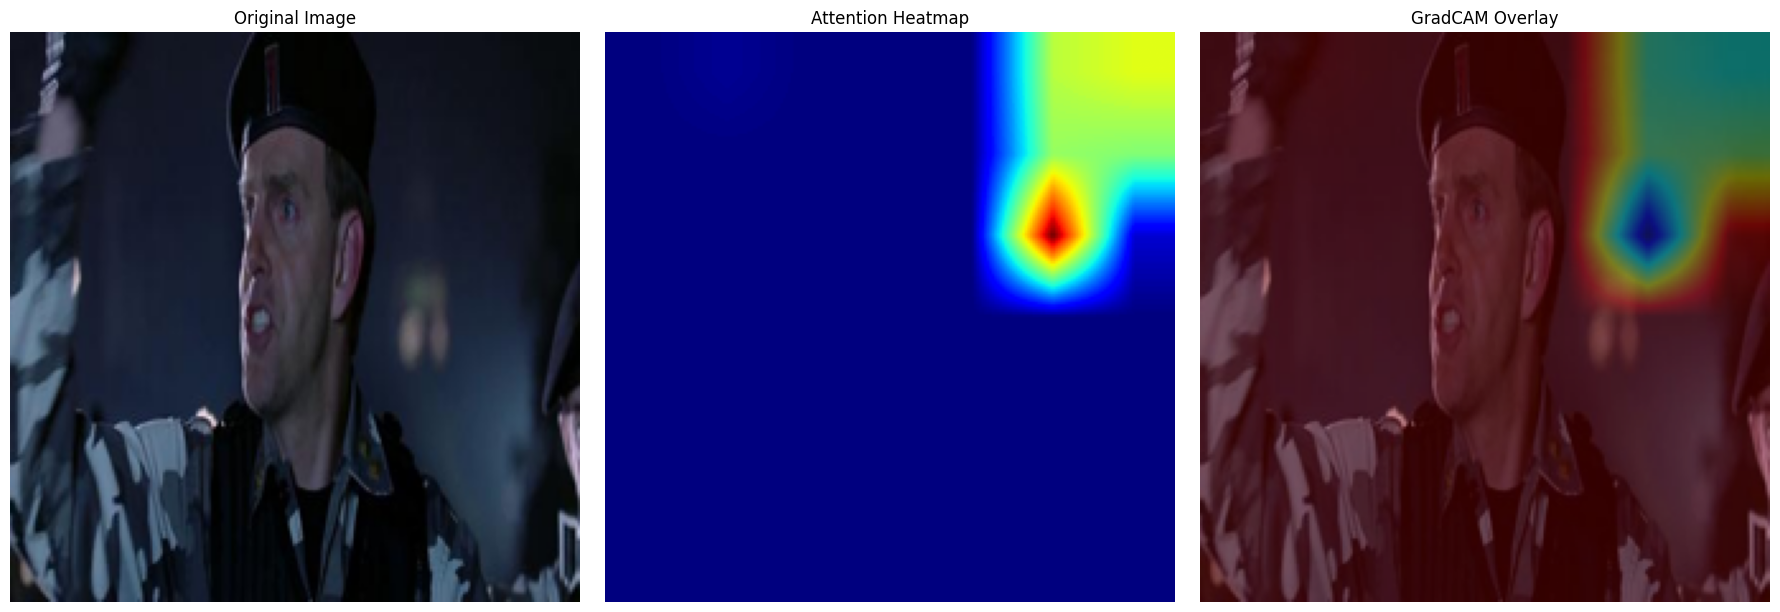


Explainability completed successfully.

Saved Files:

/content/multimodal_story_reasoning/results/gradcam/gradcam_overlay.png
/content/multimodal_story_reasoning/results/attention_maps/attention_heatmap.png
/content/multimodal_story_reasoning/results/figures/gradcam_figure.png


In [12]:
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    load_storyreasoning_dataset,
    process_image
)


BASE_PATH = "/content/multimodal_story_reasoning/results"

GRADCAM_PATH = f"{BASE_PATH}/gradcam"

ATTENTION_PATH = f"{BASE_PATH}/attention_maps"

FIGURES_PATH = f"{BASE_PATH}/figures"


os.makedirs(GRADCAM_PATH, exist_ok=True)

os.makedirs(ATTENTION_PATH, exist_ok=True)

os.makedirs(FIGURES_PATH, exist_ok=True)


dataset = load_storyreasoning_dataset()

sample = dataset["test"][0]

original_image = sample["images"][0]


input_tensor = process_image(
    original_image
).unsqueeze(0).to(device)


model.eval()


feature_maps = []

gradients = []


target_layer = None


for name, module in model.named_modules():

    if isinstance(module, torch.nn.Conv2d):

        target_layer = module


print("Using target layer:\n")

print(target_layer)


def forward_hook(module, input, output):

    feature_maps.append(output)


def backward_hook(module, grad_input, grad_output):

    gradients.append(grad_output[0])


forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)


dummy_input_ids = torch.randint(

    0,

    tokenizer.vocab_size,

    (1, 64)

).to(device)


dummy_mask = torch.ones(
    (1, 64)
).to(device)


dummy_targets = torch.randint(

    0,

    tokenizer.vocab_size,

    (1, 64)

).to(device)


pred_img, text_logits, align_loss = model(

    input_tensor,

    dummy_input_ids,

    dummy_mask,

    dummy_targets
)


score = text_logits.mean()

model.zero_grad()

score.backward()


grads = gradients[0]

fmaps = feature_maps[0]


pooled_grads = torch.mean(

    grads,

    dim=[0, 2, 3]
)


for i in range(fmaps.shape[1]):

    fmaps[:, i, :, :] *= pooled_grads[i]


heatmap = torch.mean(
    fmaps,
    dim=1
).squeeze()


heatmap = heatmap.cpu().detach().numpy()

heatmap = np.maximum(
    heatmap,
    0
)


if np.max(heatmap) != 0:

    heatmap /= np.max(heatmap)


heatmap = cv2.resize(

    heatmap,

    (224, 224)
)


heatmap_uint8 = np.uint8(
    255 * heatmap
)


heatmap_color = cv2.applyColorMap(

    heatmap_uint8,

    cv2.COLORMAP_JET
)


original_np = np.array(

    original_image.resize((224,224))
)


overlay = cv2.addWeighted(

    original_np,

    0.6,

    heatmap_color,

    0.4,

    0
)


gradcam_save_path = (

    f"{GRADCAM_PATH}/gradcam_overlay.png"
)

cv2.imwrite(

    gradcam_save_path,

    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)


attention_save_path = (

    f"{ATTENTION_PATH}/attention_heatmap.png"
)

cv2.imwrite(

    attention_save_path,

    heatmap_uint8
)


figure_path = (

    f"{FIGURES_PATH}/gradcam_figure.png"
)


plt.figure(figsize=(18,6))


plt.subplot(1,3,1)

plt.imshow(original_np)

plt.title("Original Image")

plt.axis("off")


plt.subplot(1,3,2)

plt.imshow(heatmap_uint8, cmap="jet")

plt.title("Attention Heatmap")

plt.axis("off")


plt.subplot(1,3,3)

plt.imshow(overlay)

plt.title("GradCAM Overlay")

plt.axis("off")


plt.tight_layout()

plt.savefig(

    figure_path,

    bbox_inches="tight"
)

plt.show()

plt.close()


forward_handle.remove()

backward_handle.remove()


print("\nExplainability completed successfully.\n")

print("Saved Files:\n")

print(gradcam_save_path)

print(attention_save_path)

print(figure_path)